# Generative Model Comparison on MNIST

**Models:**

| Model | Description |
|-------|-------------|
| **VAE (Flow Prior)** | VAE with normalizing-flow prior (Gaussian decoder) |
| **VAE (Gaussian Prior)** | VAE with standard N(0,I) prior (Gaussian decoder) |
| **VAE (MoG Prior)** | VAE with mixture-of-Gaussians prior (Gaussian decoder) |
| **VAE (Flow + Bernoulli)** | VAE with flow prior and Bernoulli decoder (binarised MNIST) |
| **Beta-VAE (Gaussian)** | Standard beta-VAE with N(0,I) prior |
| **DDPM (U-Net)** | Pixel-space DDPM with U-Net backbone |
| **Latent DDPM** | DDPM in the latent space of a flow-prior VAE |

All VAE components (Gaussian / MoG / Flow priors, Gaussian / Bernoulli decoders) are
ported from `src/Part A/Szymon/` and integrated into the `LatentDDPMwNB.models` package.
Any prior type and decoder type can also be used with the **Latent DDPM** pipeline.

**Notebook structure:**
1. Setup -- imports, hyperparameters, data
2. Training -- train each model
3. Evaluation -- visual comparison, FID, sampling speed, latent analysis
4. Discussion

In [11]:
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

ROOT = Path.cwd().parent  # .../Advanced-Machine-learning
if str(ROOT) not in sys.path:
    
    sys.path.insert(0, str(ROOT))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Root:   {ROOT}')


Device: cuda
Root:   c:\Users\berko\Documents\Code\Advanced-Machine-learning


In [ ]:

# --- Imports ---------------------------------------------------------
# Force-reload LatentDDPMwNB modules so code changes are picked up
# without restarting the kernel.
import importlib, sys

for mod_name in sorted(k for k in sys.modules if k.startswith('LatentDDPMwNB')):
    importlib.reload(sys.modules[mod_name])

from LatentDDPMwNB.data import get_standard_mnist, get_ddpm_mnist, get_real_images_for_fid
from LatentDDPMwNB.compare import (
    show_samples, measure_sampling_speed, evaluate_fid,
    compare_models, plot_latent_distributions, fid_vs_beta,
)

# Model wrappers (auto-registers them in ModelRegistry)
from LatentDDPMwNB.models.ddpm_unet import DDPMUNetModel
from LatentDDPMwNB.models.vae import VAEModel
from LatentDDPMwNB.models.latent_ddpm import LatentDDPMModel
from LatentDDPMwNB.models.registry import ModelRegistry

print('Registered models:', ModelRegistry.list())


Registered models: []


In [13]:

# --- Hyperparameters -------------------------------------------------
TEST_MODE = True   # Set to False for full training

BATCH_SIZE   = 64
LATENT_DIM   = 16
VAE_HIDDEN   = 2048
DDPM_T       = 1000

if TEST_MODE:
    # Flow VAE
    VAE_FLOW_EPOCHS = 2
    VAE_FLOW_LR     = 1e-3
    # Beta-VAE (Gaussian prior)
    BETA_VAE_EPOCHS = 2
    BETA_VAE_LR     = 1e-3
    # DDPM U-Net
    DDPM_UNET_EPOCHS = 2
    DDPM_UNET_LR     = 2e-4
    # Latent DDPM
    LDDPM_BETA              = 1.0
    LDDPM_VAE_EPOCHS        = 2
    LDDPM_VAE_WARMUP_EPOCHS = 1
    LDDPM_DDPM_EPOCHS       = 2
    LDDPM_VAE_LR            = 1e-3
    LDDPM_DDPM_LR           = 2e-4
    # FID
    N_FID = 100
    print('** TEST MODE: using minimal epochs **')
else:
    # Flow VAE
    VAE_FLOW_EPOCHS = 50
    VAE_FLOW_LR     = 1e-3
    # Beta-VAE (Gaussian prior)
    BETA_VAE_EPOCHS = 50
    BETA_VAE_LR     = 1e-3
    # DDPM U-Net
    DDPM_UNET_EPOCHS = 50 if device == 'cuda' else 10
    DDPM_UNET_LR     = 2e-4
    # Latent DDPM
    LDDPM_BETA              = 1.0
    LDDPM_VAE_EPOCHS        = 100 if device == 'cuda' else 60
    LDDPM_VAE_WARMUP_EPOCHS = LDDPM_VAE_EPOCHS // 2
    LDDPM_DDPM_EPOCHS       = 50 if device == 'cuda' else 20
    LDDPM_VAE_LR            = 1e-3
    LDDPM_DDPM_LR           = 2e-4
    # FID
    N_FID = 1000

# Output directory
OUTDIR = Path('project/outputs')
OUTDIR.mkdir(parents=True, exist_ok=True)


** TEST MODE: using minimal epochs **


In [14]:
# --- Data ------------------------------------------------------------
# Standard MNIST [0,1] -- used by Latent DDPM and VAE
train_loader, test_loader = get_standard_mnist(BATCH_SIZE)

# DDPM MNIST [-1,1] -- used by the pixel-space DDPM U-Net
train_loader_ddpm, _ = get_ddpm_mnist(BATCH_SIZE)

print(f'Train batches (standard): {len(train_loader)}')
print(f'Train batches (DDPM):     {len(train_loader_ddpm)}')

Train batches (standard): 938
Train batches (DDPM):     938


---
# 2. Training

## 2.1 VAE (Flow Prior)

β-VAE training: 100%|██████████| 1876/1876 [01:13<00:00, 25.56it/s, beta=1.000000, epoch=2/2, loss=740.1836, lr=5.00e-04]


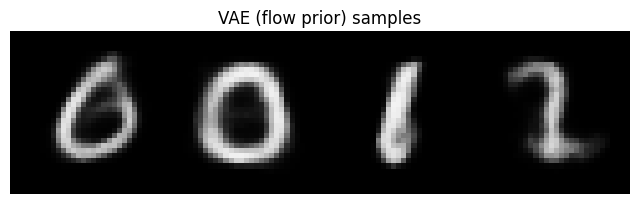

tensor([[[[1.6743e-03, 1.8900e-03, 1.6144e-03,  ..., 1.4730e-03,
           1.6110e-03, 1.6060e-03],
          [1.6375e-03, 1.8432e-03, 1.5131e-03,  ..., 1.7272e-03,
           1.6015e-03, 1.4342e-03],
          [1.4439e-03, 1.8739e-03, 1.9936e-03,  ..., 1.5568e-03,
           1.8612e-03, 1.4977e-03],
          ...,
          [1.6781e-03, 1.7179e-03, 1.4679e-03,  ..., 1.4445e-03,
           1.5544e-03, 1.4277e-03],
          [1.7587e-03, 1.6493e-03, 1.7245e-03,  ..., 1.7624e-03,
           1.4735e-03, 1.5177e-03],
          [1.3740e-03, 1.6773e-03, 1.4949e-03,  ..., 1.5585e-03,
           1.4996e-03, 1.5838e-03]]],


        [[[2.7778e-03, 2.4232e-03, 3.2728e-03,  ..., 3.0451e-03,
           2.8476e-03, 3.0499e-03],
          [2.6206e-03, 3.0515e-03, 2.4462e-03,  ..., 2.6711e-03,
           3.2234e-03, 2.5565e-03],
          [2.9338e-03, 2.5980e-03, 2.8892e-03,  ..., 3.0854e-03,
           2.5594e-03, 3.0485e-03],
          ...,
          [2.6688e-03, 2.7675e-03, 3.0294e-03,  ..., 2.67

In [15]:
vae_flow = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='flow', model_name='vae_flow',
)
vae_flow.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_flow.save(OUTDIR / 'vae_flow.pt')
show_samples(vae_flow, n=4, title='VAE (flow prior) samples',
             save_path=OUTDIR / 'samples_vae_flow.png')

β-VAE training: 100%|██████████| 1876/1876 [00:48<00:00, 38.78it/s, beta=1.000000, epoch=2/2, loss=738.8721, lr=5.00e-04]


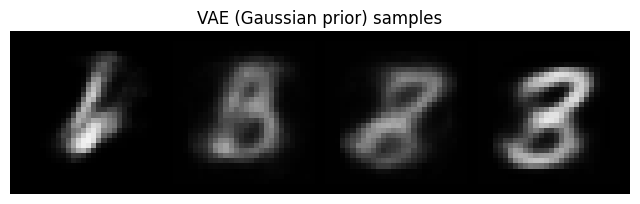

tensor([[[[0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002],
          [0.0002, 0.0002, 0.0002,  ..., 0.0003, 0.0002, 0.0002],
          [0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002],
          ...,
          [0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0003, 0.0002],
          [0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002],
          [0.0002, 0.0003, 0.0002,  ..., 0.0003, 0.0002, 0.0002]]],


        [[[0.0065, 0.0068, 0.0068,  ..., 0.0063, 0.0071, 0.0067],
          [0.0067, 0.0065, 0.0073,  ..., 0.0060, 0.0066, 0.0059],
          [0.0074, 0.0069, 0.0069,  ..., 0.0060, 0.0074, 0.0063],
          ...,
          [0.0075, 0.0072, 0.0060,  ..., 0.0066, 0.0067, 0.0061],
          [0.0063, 0.0073, 0.0072,  ..., 0.0070, 0.0079, 0.0059],
          [0.0069, 0.0072, 0.0071,  ..., 0.0077, 0.0072, 0.0064]]],


        [[[0.0050, 0.0054, 0.0049,  ..., 0.0047, 0.0055, 0.0044],
          [0.0050, 0.0047, 0.0045,  ..., 0.0055, 0.0054, 0.0044],
          [0.0052, 0.0053, 0.0050,  ..

In [16]:
vae_gauss = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='gaussian', model_name='vae_gauss',
)
vae_gauss.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_gauss.save(OUTDIR / 'vae_gauss.pt')
show_samples(vae_gauss, n=4, title='VAE (Gaussian prior) samples',
             save_path=OUTDIR / 'samples_vae_gauss.png')

## 2.1b VAE (MoG Prior)

β-VAE training: 100%|██████████| 1876/1876 [00:56<00:00, 33.49it/s, beta=1.000000, epoch=2/2, loss=740.0262, lr=5.00e-04]


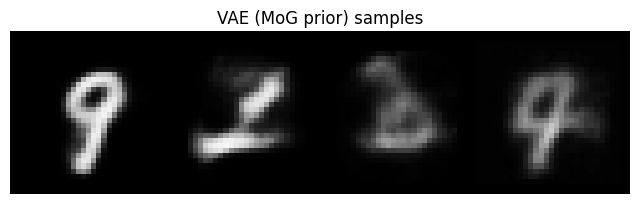

tensor([[[[0.0007, 0.0006, 0.0006,  ..., 0.0007, 0.0006, 0.0007],
          [0.0007, 0.0006, 0.0006,  ..., 0.0007, 0.0006, 0.0007],
          [0.0007, 0.0006, 0.0009,  ..., 0.0008, 0.0007, 0.0006],
          ...,
          [0.0007, 0.0007, 0.0008,  ..., 0.0007, 0.0007, 0.0006],
          [0.0006, 0.0005, 0.0007,  ..., 0.0006, 0.0009, 0.0007],
          [0.0006, 0.0008, 0.0008,  ..., 0.0007, 0.0007, 0.0007]]],


        [[[0.0007, 0.0008, 0.0008,  ..., 0.0008, 0.0006, 0.0008],
          [0.0007, 0.0007, 0.0007,  ..., 0.0007, 0.0007, 0.0007],
          [0.0006, 0.0008, 0.0005,  ..., 0.0007, 0.0007, 0.0009],
          ...,
          [0.0008, 0.0006, 0.0007,  ..., 0.0008, 0.0007, 0.0007],
          [0.0007, 0.0008, 0.0008,  ..., 0.0006, 0.0006, 0.0007],
          [0.0007, 0.0007, 0.0006,  ..., 0.0007, 0.0008, 0.0007]]],


        [[[0.0025, 0.0024, 0.0025,  ..., 0.0025, 0.0027, 0.0028],
          [0.0025, 0.0026, 0.0027,  ..., 0.0024, 0.0024, 0.0025],
          [0.0023, 0.0026, 0.0028,  ..

In [17]:
vae_mog = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='mog', mog_components=10, model_name='vae_mog',
)
vae_mog.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_mog.save(OUTDIR / 'vae_mog.pt')
show_samples(vae_mog, n=4, title='VAE (MoG prior) samples',
             save_path=OUTDIR / 'samples_vae_mog.png')

## 2.1c VAE (Flow Prior, Bernoulli Decoder)

Uses a **Bernoulli decoder** (for binarised MNIST) instead of the default Gaussian decoder.
This matches the original Part A implementation.

In [18]:
vae_bernoulli = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='flow', decoder_type='bernoulli', model_name='vae_bernoulli',
)
vae_bernoulli.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_bernoulli.save(OUTDIR / 'vae_bernoulli.pt')
show_samples(vae_bernoulli, n=4, title='VAE (Flow prior, Bernoulli decoder) samples',
             save_path=OUTDIR / 'samples_vae_bernoulli.png')

ValueError: Expected value argument (Tensor of shape (64, 784)) to be within the support (Boolean()) of the distribution Bernoulli(logits: torch.Size([64, 784])), but found invalid values:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')

## 2.2 Beta-VAE (Gaussian Prior)

β-VAE training: 100%|██████████| 1876/1876 [00:48<00:00, 38.32it/s, beta=1.000000, epoch=2/2, loss=741.7521, lr=5.00e-04]


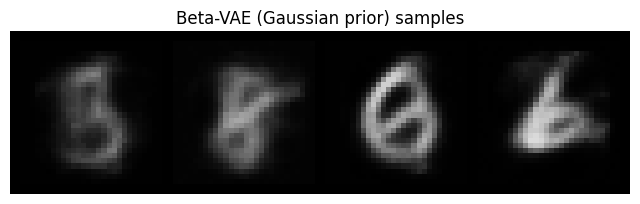

tensor([[[[0.0052, 0.0053, 0.0049,  ..., 0.0044, 0.0048, 0.0051],
          [0.0050, 0.0050, 0.0048,  ..., 0.0047, 0.0050, 0.0050],
          [0.0045, 0.0051, 0.0046,  ..., 0.0048, 0.0059, 0.0046],
          ...,
          [0.0050, 0.0044, 0.0044,  ..., 0.0046, 0.0049, 0.0053],
          [0.0051, 0.0045, 0.0051,  ..., 0.0051, 0.0050, 0.0049],
          [0.0047, 0.0052, 0.0053,  ..., 0.0053, 0.0047, 0.0050]]],


        [[[0.0136, 0.0145, 0.0145,  ..., 0.0152, 0.0139, 0.0163],
          [0.0149, 0.0129, 0.0136,  ..., 0.0149, 0.0137, 0.0155],
          [0.0135, 0.0141, 0.0126,  ..., 0.0146, 0.0150, 0.0156],
          ...,
          [0.0148, 0.0137, 0.0140,  ..., 0.0144, 0.0148, 0.0141],
          [0.0142, 0.0142, 0.0163,  ..., 0.0150, 0.0138, 0.0152],
          [0.0134, 0.0166, 0.0130,  ..., 0.0150, 0.0147, 0.0150]]],


        [[[0.0053, 0.0048, 0.0048,  ..., 0.0051, 0.0054, 0.0055],
          [0.0049, 0.0052, 0.0052,  ..., 0.0050, 0.0052, 0.0054],
          [0.0044, 0.0056, 0.0045,  ..

In [ ]:
beta_vae = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='gaussian', model_name='beta_vae',
)
beta_vae.train_model(train_loader, epochs=BETA_VAE_EPOCHS, lr=BETA_VAE_LR)
beta_vae.save(OUTDIR / 'beta_vae.pt')
show_samples(beta_vae, n=4, title='Beta-VAE (Gaussian prior) samples',
             save_path=OUTDIR / 'samples_beta_vae.png')

## 2.3 DDPM U-Net (Pixel-space DDPM)

Training: 100%|██████████| 1876/1876 [01:20<00:00, 23.17it/s, epoch=2/2, loss=⠀    123.6732]


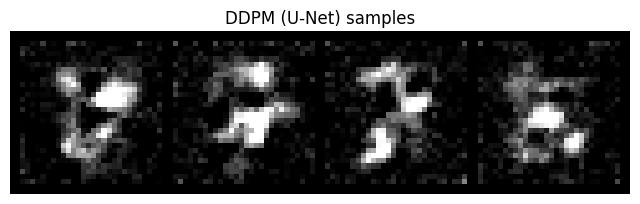

tensor([[[[0.0000, 0.0000, 0.0674,  ..., 0.0551, 0.0000, 0.0507],
          [0.1494, 0.1048, 0.0027,  ..., 0.0131, 0.0000, 0.1197],
          [0.2297, 0.0336, 0.1229,  ..., 0.0583, 0.0114, 0.0000],
          ...,
          [0.2879, 0.0840, 0.0000,  ..., 0.0818, 0.0000, 0.0000],
          [0.0166, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0610, 0.1059, 0.2237,  ..., 0.0000, 0.0000, 0.0157]]],


        [[[0.3334, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.1446],
          [0.0000, 0.0000, 0.0546,  ..., 0.1138, 0.1679, 0.1092],
          [0.0000, 0.0568, 0.0000,  ..., 0.1696, 0.0000, 0.0670],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0784],
          [0.0909, 0.0758, 0.0637,  ..., 0.0319, 0.0000, 0.0000],
          [0.0350, 0.3294, 0.0000,  ..., 0.1192, 0.0000, 0.0000]]],


        [[[0.3207, 0.0621, 0.0000,  ..., 0.0000, 0.0088, 0.3034],
          [0.0072, 0.0658, 0.1805,  ..., 0.0000, 0.0573, 0.0953],
          [0.0578, 0.0062, 0.0000,  ..

In [ ]:
ddpm = DDPMUNetModel(device=device, T=DDPM_T)
ddpm.train_model(train_loader_ddpm, epochs=DDPM_UNET_EPOCHS, lr=DDPM_UNET_LR)
ddpm.save(OUTDIR / 'ddpm_unet.pt')
show_samples(ddpm, n=4, title='DDPM (U-Net) samples',
             save_path=OUTDIR / 'samples_ddpm_unet.png')

## 2.4 Latent DDPM (Flow-prior VAE + DDPM in z-space)

In [ ]:
latent_ddpm = LatentDDPMModel(
    device=device,
    beta=LDDPM_BETA,
    latent_dim=LATENT_DIM,
    vae_hidden=VAE_HIDDEN,
    T=DDPM_T,
)

# Stage 1: Train the flow-prior VAE inside Latent DDPM
print('Stage 1: Training flow-prior VAE (Gaussian likelihood)...')
import inspect
sig = inspect.signature(latent_ddpm.train_vae)
if 'beta_warmup_epochs' in sig.parameters:
    latent_ddpm.train_vae(
        train_loader,
        epochs=LDDPM_VAE_EPOCHS,
        lr=LDDPM_VAE_LR,
        beta_warmup_epochs=int(LDDPM_VAE_WARMUP_EPOCHS),
    )
else:
    latent_ddpm.train_vae(
        train_loader,
        epochs=LDDPM_VAE_EPOCHS,
        lr=LDDPM_VAE_LR,
    )

In [ ]:
# Show comparison: Real vs reconstruction vs flow-prior sample
print('\n--- Flow-Prior VAE Quality Check ---')

real_batch = next(iter(test_loader))
if isinstance(real_batch, (list, tuple)):
    real_batch = real_batch[0]
real_flat = real_batch[:8].to(device)
if real_flat.dim() > 2:
    real_flat = real_flat.view(real_flat.size(0), -1)

with torch.no_grad():
    q = latent_ddpm.vae.encode(real_flat)
    recon = latent_ddpm.vae.decode_mean(q.mean)
    prior_gen = latent_ddpm.vae.sample(n_samples=8).to(device)

real_imgs = real_flat.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
recon_imgs = recon.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
gen_imgs = prior_gen.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0, i].imshow(real_imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title('Real' if i == 0 else '', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title('Recon' if i == 0 else '', fontsize=10)
    axes[1, i].axis('off')
    axes[2, i].imshow(gen_imgs[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title('Prior Gen' if i == 0 else '', fontsize=10)
    axes[2, i].axis('off')

fig.suptitle('Flow-Prior VAE: Real vs Reconstruction vs Prior Samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'beta_vae_quality_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('Quality check saved to beta_vae_quality_check.png')

In [ ]:
# Stage 2: Train the latent DDPM
print('\nStage 2: Training DDPM in latent space...')
latent_ddpm.train_ddpm(train_loader, epochs=LDDPM_DDPM_EPOCHS, lr=LDDPM_DDPM_LR)

latent_ddpm.save(OUTDIR / 'latent_ddpm.pt')
print('Saved latent DDPM model.')

In [ ]:
# DIAGNOSTIC: Compare VAE Prior vs Latent DDPM
print('\n--- Latent DDPM Diagnostic ---')
print('Comparing: VAE Prior Sampling vs Trained DDPM in Latent Space\n')

real_batch = next(iter(test_loader))
if isinstance(real_batch, (list, tuple)):
    real_batch = real_batch[0]
real_flat = real_batch[:8].to(device)
if real_flat.dim() > 2:
    real_flat = real_flat.view(real_flat.size(0), -1)

with torch.no_grad():
    q = latent_ddpm.vae.encode(real_flat)
    vae_recon = latent_ddpm.vae.decode_mean(q.mean)
    vae_prior_gen = latent_ddpm.vae.sample(n_samples=8).to(device)
    ddpm_samples = latent_ddpm.sample(n_samples=8).to(device)
    if ddpm_samples.dim() == 4:
        ddpm_samples = ddpm_samples.view(ddpm_samples.size(0), -1)

real_imgs = real_flat.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
recon_imgs = vae_recon.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
vae_prior_imgs = vae_prior_gen.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
ddpm_imgs = ddpm_samples.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i in range(8):
    axes[0, i].imshow(real_imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title('Real' if i == 0 else '', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title('VAE Recon' if i == 0 else '', fontsize=10)
    axes[1, i].axis('off')
    axes[2, i].imshow(vae_prior_imgs[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title('VAE Prior' if i == 0 else '', fontsize=10)
    axes[2, i].axis('off')
    axes[3, i].imshow(ddpm_imgs[i, 0].numpy(), cmap='gray')
    axes[3, i].set_title('Latent DDPM' if i == 0 else '', fontsize=10)
    axes[3, i].axis('off')

fig.suptitle('Latent DDPM Diagnostic: Where Does Quality Break?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'latent_ddpm_diagnostic.png', dpi=120, bbox_inches='tight')
plt.show()

print('DIAGNOSIS:')
print('  Row 1 (Real): Ground truth')
print('  Row 2 (VAE Recon): Should be sharp -- checks if VAE encoder works')
print('  Row 3 (VAE Prior): z ~ flow prior -- checks if VAE prior is aligned')
print('  Row 4 (Latent DDPM): z ~ DDPM -- checks if DDPM improved the prior')
print()
print('If Row 3 is blurry: beta is too low -- increase beta')
print('If Row 3 is OK but Row 4 is worse: DDPM training failed -- more epochs needed')
print('Diagnostic saved to latent_ddpm_diagnostic.png')

---
# 3. Evaluation

## 3.1 Visual Comparison: Real MNIST vs Generated Samples

In [ ]:
def show_comparison(real_loader, models, n_samples=8, save_path=None):
    """Top row = real MNIST, then one row per model with generated samples."""
    real_batch = next(iter(real_loader))
    if isinstance(real_batch, (list, tuple)):
        real_batch = real_batch[0]
    real_imgs = real_batch[:n_samples].cpu()
    if real_imgs.dim() == 2:
        real_imgs = real_imgs.view(-1, 1, 28, 28)
    real_imgs = real_imgs.clamp(0.0, 1.0)

    n_rows = 1 + len(models)
    fig, axes = plt.subplots(n_rows, 1, figsize=(n_samples * 2, 2.2 * n_rows))
    if n_rows == 1:
        axes = [axes]

    grid_real = make_grid(real_imgs, nrow=n_samples, padding=2, normalize=False)
    axes[0].imshow(grid_real.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
    axes[0].set_title('Real MNIST', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    for i, m in enumerate(models):
        with torch.no_grad():
            gen = m.sample(n_samples).cpu().clamp(0.0, 1.0)
        if gen.dim() == 2:
            gen = gen.view(-1, 1, 28, 28)
        grid_gen = make_grid(gen, nrow=n_samples, padding=2, normalize=False)
        axes[i + 1].imshow(grid_gen.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
        axes[i + 1].set_title(f'{m.name} (generated)', fontsize=14)
        axes[i + 1].axis('off')

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

# All models (including new VAE variants)
models_to_eval = [vae_flow, vae_gauss, vae_mog, vae_bernoulli, beta_vae, ddpm, latent_ddpm]

show_comparison(
    train_loader, models_to_eval, n_samples=8,
    save_path=OUTDIR / 'comparison_real_vs_generated.png',
)

## 3.2 FID Scores

In [ ]:
fid_results = {}
for m in models_to_eval:
    fid = evaluate_fid(m, n_gen=N_FID, device=device)
    fid_results[m.name] = fid
    print(f'{m.name:20s}  FID = {fid:.2f}')

## 3.3 FID vs β (Latent DDPM)

Sweep over different β values for the β-VAE inside the Latent DDPM.

In [ ]:
# β values to sweep (adjust as needed)
betas_to_test = [1e-6, 1e-4, 1e-2, 1e-1, 1.0]

beta_fid_results = fid_vs_beta(
    betas=betas_to_test,
    train_loader=train_loader,
    device=device,
    latent_dim=LATENT_DIM,
    vae_epochs=LDDPM_VAE_EPOCHS,
    ddpm_epochs=LDDPM_DDPM_EPOCHS,
    n_fid=N_FID,
    save_path=OUTDIR / 'fid_vs_beta.png',
)

for b, f in beta_fid_results.items():
    print(f'  β = {b:.1e}  →  FID = {f:.2f}')

## 3.4 Sampling Speed

In [ ]:
speed_results = {}
for m in models_to_eval:
    sr = measure_sampling_speed(m, n_samples=100)
    speed_results[m.name] = sr
    print(f"{m.name:20s}  {sr['samples_per_sec']:.1f} samples/s  "
          f"({sr['total_time_s']:.2f}s for {sr['n_samples']} samples)")

## 3.5 Latent Space Analysis

Compare three distributions in the first two latent dimensions:
- **VAE prior** — $\mathcal{N}(0, I)$
- **Aggregate posterior** — $\frac{1}{N} \sum q(z \mid x_i)$
- **Learned DDPM prior** — samples from the latent-space DDPM

In [ ]:
plot_latent_distributions(
    latent_ddpm,
    train_loader,
    dims=(0, 1),
    n_samples=5000,
    save_path=OUTDIR / 'latent_distributions.png',
)